In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm          # <-- add this

plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)


In [25]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

T = 10000      # <-- bumped from 1000 to 10000
ALPHA = 0.05    # significance level for 95% prediction intervals


In [26]:
""" Simulate AR(1)-HMM """

# State parameters
mu  = np.array([0.0, 0.0])   # intercepts (add if not there)
rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)

states[0] = np.random.choice([0, 1])
y[0] = np.random.normal()

for t in range(1, T):
    states[t] = np.random.choice([0, 1], p=P[states[t-1]])
    s = states[t]
    y[t] = mu[s] + rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    if t % 1000 == 0:   # every 1000 instead of 100
        print(f"{'iteration ' + str(t):<20s}{'state: ' + str(s):<15s}y[{t}]: {y[t]:.4f}")


iteration 1000      state: 1       y[1000]: 0.3651
iteration 2000      state: 0       y[2000]: -0.0725
iteration 3000      state: 1       y[3000]: 0.5461
iteration 4000      state: 1       y[4000]: 0.2574
iteration 5000      state: 0       y[5000]: 0.2733
iteration 6000      state: 0       y[6000]: 0.6767
iteration 7000      state: 0       y[7000]: -0.0712
iteration 8000      state: 1       y[8000]: -0.0055
iteration 9000      state: 0       y[9000]: 1.1625


In [27]:
""" Prediction Intervals — regime-conditional (uses the TRUE states as oracle) """

# 1-step-ahead predictions using the TRUE state at time t
y_hat  = np.zeros(T)
lower  = np.zeros(T)
upper  = np.zeros(T)

for t in range(1, T):
    s = states[t - 1]                      # current regime
    y_hat[t] = mu[s] + rho[s] * y[t - 1]
    z = norm.ppf(1 - ALPHA / 2)            # 1.96 for 95%
    lower[t] = y_hat[t] - z * sigma[s]
    upper[t] = y_hat[t] + z * sigma[s]

# Evaluate: skip t=0 (no prediction)
y_actual = y[1:]
l, u, yh = lower[1:], upper[1:], y_hat[1:]

coverage  = np.mean((y_actual >= l) & (y_actual <= u))
avg_width = np.mean(u - l)
IS        = np.mean(
    (u - l)
    + (2 / ALPHA) * np.maximum(l - y_actual, 0)
    + (2 / ALPHA) * np.maximum(y_actual - u, 0)
)

print(f"Coverage:  {coverage:.4f}  (target: {1 - ALPHA:.2f})")
print(f"Avg Width: {avg_width:.4f}")
print(f"Interval Score (IS): {IS:.4f}  (lower is better)")


Coverage:  0.9405  (target: 0.95)
Avg Width: 2.9281
Interval Score (IS): 3.6757  (lower is better)


In [28]:
""" Baselines: compare 3 naive predictors """

def interval_score(y_true, l, u, alpha=0.05):
    return np.mean(
        (u - l)
        + (2 / alpha) * np.maximum(l - y_true, 0)
        + (2 / alpha) * np.maximum(y_true - u, 0)
    )

# Baseline 1: always predict 0
y0   = np.zeros(T - 1)
std0 = np.std(y[1:])
z    = norm.ppf(1 - ALPHA / 2)
l0, u0 = y0 - z * std0, y0 + z * std0

# Baseline 2: repeat last value
y_last    = y[:-1]
resid_rep = y[1:] - y[:-1]
std_rep   = np.std(resid_rep)
l_rep     = y_last - z * std_rep
u_rep     = y_last + z * std_rep

# Baseline 3: 3-period rolling mean
y_roll    = np.array([np.mean(y[max(0, t-3):t]) for t in range(1, T)])
resid_roll = y[1:] - y_roll
std_roll  = np.std(resid_roll)
l_roll    = y_roll - z * std_roll
u_roll    = y_roll + z * std_roll

y_true = y[1:]

results = {
    "AR(1)-HMM (oracle)": (l, u),
    "Baseline: always 0": (l0, u0),
    "Baseline: repeat last": (l_rep, u_rep),
    "Baseline: 3-period mean": (l_roll, u_roll),
}

print(f"{'Model':<30s}  {'Coverage':>10s}  {'Avg Width':>10s}  {'IS (↓ better)':>14s}")
print("-" * 70)
for name, (lo, hi) in results.items():
    cov = np.mean((y_true >= lo) & (y_true <= hi))
    wid = np.mean(hi - lo)
    IS_val = interval_score(y_true, lo, hi, ALPHA)
    print(f"{name:<30s}  {cov:>10.4f}  {wid:>10.4f}  {IS_val:>14.4f}")


Model                             Coverage   Avg Width   IS (↓ better)
----------------------------------------------------------------------
AR(1)-HMM (oracle)                  0.9405      2.9281          3.6757
Baseline: always 0                  0.9275      4.5836          6.7723
Baseline: repeat last               0.9427      3.4988          4.4959
Baseline: 3-period mean             0.9373      3.7472          4.9716


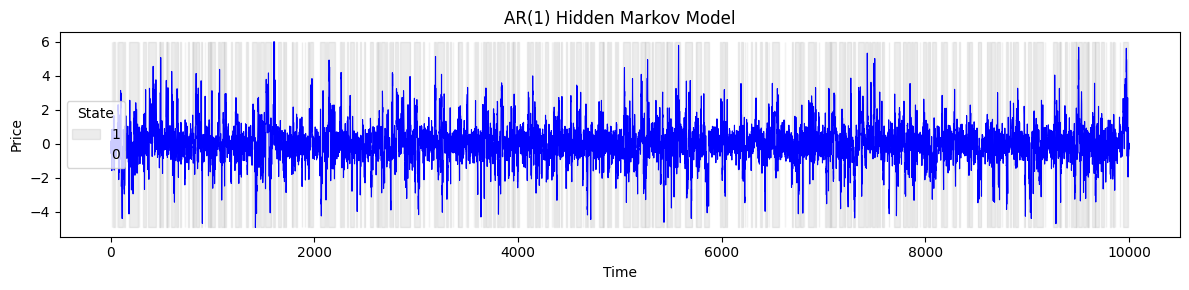

In [29]:
""" Plotting figure """

# Figure size 
plt.figure(figsize=(12,3))

# Plotting the line segments and filling in gaps
plt.plot(y, color="blue", linewidth=0.8)
plt.fill_between(range(T), y.min(), y.max(), where=(states==1), alpha=0.15, color="grey", label="1")
plt.fill_between(range(T), y.min(), y.max(), where=(states==0), alpha=0.15, color="white", label="0")

# Title, axes labels, and legend 
plt.title("AR(1) Hidden Markov Model")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(title="State")

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, "ar1-hmm.pdf"), bbox_inches="tight")
plt.show()

In [30]:
""" Final Summary """

print("=" * 70)
print("AR(1)-HMM SIMULATION SUMMARY")
print("=" * 70)
print(f"  T = {T:,}   |   States: 2   |   alpha = {ALPHA}")
print(f"  rho   = {rho}   sigma = {sigma}")
print(f"  P = [[{P[0,0]}, {P[0,1]}], [{P[1,0]}, {P[1,1]}]]")
print()

# State occupancy
n0 = np.sum(states == 0)
n1 = np.sum(states == 1)
print(f"  State 0 occupancy: {n0:,} ({100*n0/T:.1f}%)")
print(f"  State 1 occupancy: {n1:,} ({100*n1/T:.1f}%)")
print()

print("-" * 70)
print(f"{'Model':<28}  {'Coverage':>9}  {'Avg Width':>10}  {'IS (↓ better)':>14}")
print("-" * 70)
for name, (lo, hi) in results.items():
    cov   = np.mean((y_true >= lo) & (y_true <= hi))
    wid   = np.mean(hi - lo)
    IS_v  = interval_score(y_true, lo, hi, ALPHA)
    marker = " ✓" if name.startswith("AR") else ""
    print(f"{name:<28}  {cov:>9.4f}  {wid:>10.4f}  {IS_v:>14.4f}{marker}")
print("-" * 70)
print()

# What to look for
print("Notes:")
print("  Coverage target: 0.9500")
print("  IS = (u-l) + penalties for misses. Lower is strictly better.")
print("  HMM oracle wins if its IS < all baselines at ~correct coverage.")
print("=" * 70)


AR(1)-HMM SIMULATION SUMMARY
  T = 10,000   |   States: 2   |   alpha = 0.05
  rho   = [0.2 0.8]   sigma = [0.5 1. ]
  P = [[0.95, 0.05], [0.05, 0.95]]

  State 0 occupancy: 5,061 (50.6%)
  State 1 occupancy: 4,939 (49.4%)

----------------------------------------------------------------------
Model                          Coverage   Avg Width   IS (↓ better)
----------------------------------------------------------------------
AR(1)-HMM (oracle)               0.9405      2.9281          3.6757 ✓
Baseline: always 0               0.9275      4.5836          6.7723
Baseline: repeat last            0.9427      3.4988          4.4959
Baseline: 3-period mean          0.9373      3.7472          4.9716
----------------------------------------------------------------------

Notes:
  Coverage target: 0.9500
  IS = (u-l) + penalties for misses. Lower is strictly better.
  HMM oracle wins if its IS < all baselines at ~correct coverage.
